In [1]:
import glob, os, pandas
import matplotlib, matplotlib.pyplot

PN samples across all groups: ['PN2', 'PN5', 'PN73']

Group 03: matched 9 files


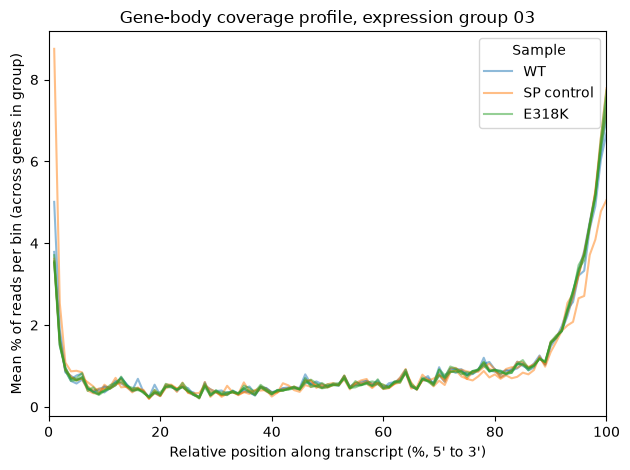


Group 07: matched 9 files


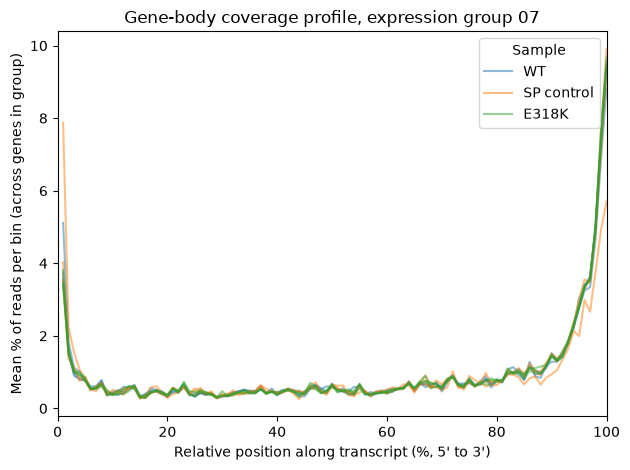


Group 12: matched 9 files


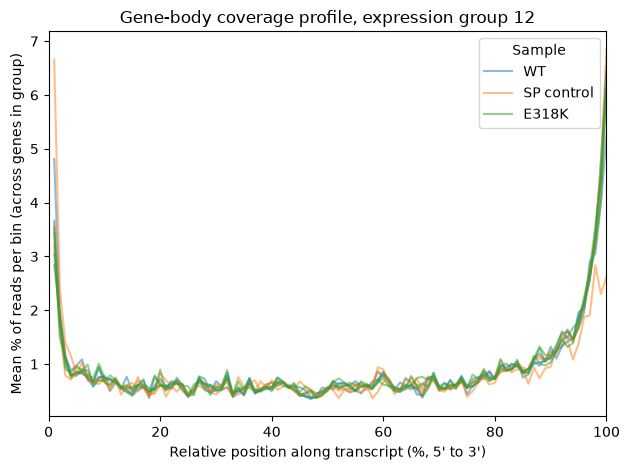


Group 20: matched 9 files


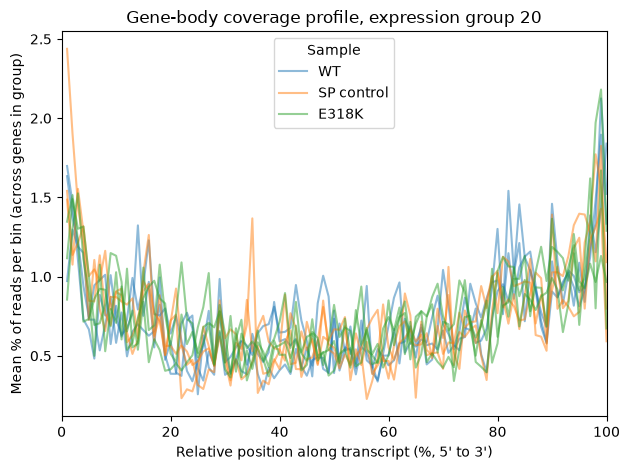

In [12]:
LABEL_MAP = {
    "PN73": "E318K",
    "PN2": "WT",
    "PN5": "SP control",
}

METAGENE_DIR = "/Users/adrian/research/095/metagene_profiles"
GROUPS = ["03", "07", "12", "20"]

all_pn_samples = sorted(set(
    os.path.basename(f).replace("metagene_profile_", "").split("_group_")[0].split("_Rep")[0]
    for f in glob.glob(os.path.join(METAGENE_DIR, "*_group_*.tsv"))
    if "gene_summary" not in f
))
cmap = matplotlib.pyplot.get_cmap("tab10")
color_lookup = {pn: cmap(i) for i, pn in enumerate(all_pn_samples)}
print("PN samples across all groups:", all_pn_samples)

for GROUP in GROUPS:
    pattern = os.path.join(METAGENE_DIR, f"*_group_{GROUP}.tsv")
    files = sorted(glob.glob(pattern))
    print(f"\nGroup {GROUP}: matched {len(files)} files")

    if not files:
        print(f"WARNING: no files found for group {GROUP}, skipping")
        continue

    fig, ax = matplotlib.pyplot.subplots()
    seen_labels = set()
    for f in files:
        base = os.path.basename(f).replace("metagene_profile_", "").replace(f"_group_{GROUP}.tsv", "")
        pn_sample = base.split("_Rep")[0]
        df = pandas.read_csv(f, sep="\t")
        gene_cols = [c for c in df.columns if c != "percent_rank"]
        mean_profile = df[gene_cols].mean(axis=1)

        display_label = LABEL_MAP.get(pn_sample, pn_sample)
        label = display_label if pn_sample not in seen_labels else None
        seen_labels.add(pn_sample)
        ax.plot(df["percent_rank"], mean_profile, color=color_lookup[pn_sample], label=label, alpha=0.5)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Relative position along transcript (%, 5' to 3')")
    ax.set_ylabel("Mean % of reads per bin (across genes in group)")
    ax.set_title(f"Gene-body coverage profile, expression group {GROUP}")
    ax.legend(title="Sample")
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()